In [4]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path       
import networkx as nx
import torch
from torch_geometric.data import Data

# Event-level representations

In [5]:
root_dir = Path('statsbomb_data')

# get competition data
comp_path = root_dir / "data" / "competitions.json"
competitions_data = json.loads(comp_path.read_text(encoding="utf-8"))
competitions_df = pd.DataFrame(competitions_data)

# get match data
competition_id = 43
season_id = 106
match_path = root_dir / "data" / "matches" / str(competition_id) / f"{season_id}.json"
match_data = json.loads(match_path.read_text(encoding="utf-8"))
match_df = pd.DataFrame(match_data)

# get event data
match_id = 3857256
events_path = root_dir / "data" / "events" / f"{match_id}.json"
events_data = json.loads(events_path.read_text(encoding="utf-8"))
events_df = pd.DataFrame(events_data)

# get 360 data
threesixty_path = root_dir / "data" / "three-sixty" / f"{match_id}.json"
threesixty_data = json.loads(threesixty_path.read_text(encoding="utf-8"))
threesixty_df = pd.DataFrame(threesixty_data)

# each row = one event with 360 context.
events_full = events_df.merge(threesixty_df, right_on= 'event_uuid', left_on = 'id', how="left") 
events_full['competition'] = competitions_df[competitions_df['competition_id']==competition_id].iloc[0].competition_name
events_full['season'] = competitions_df[competitions_df['season_id']==season_id].iloc[0].season_name
events_full['match'] = match_id

Some things to note:

"actor": true <-> events.player

For all other players in freeze_frame we do not know their identity, we just known if there are a teammate/opponent, what their position is, and if they are goalkeeper

Use case: actor node is mapped to a player, all else are anonymous, contextual nodes. We can learn how a player acts under a certain context, and then aggregate their decisions over all different events


    - Run a GNN on each graph

    - Extract actor node embeddings

    - Aggregate per actor_player_id

    - Compare embeddings == similarity

In [10]:
# helper function
def euclidean(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)


def build_nodes(freeze_frame):
    node_features = []
    actor_idx = None

    for i, p in enumerate(freeze_frame):
        x, y = p["location"]

        # binary features of available information
        is_teammate = int(p["teammate"])
        is_actor = int(p["actor"])
        is_keeper = int(p["keeper"])

        if is_actor:
            actor_idx = i # maps node to player

        node_features.append([
            x, y,
            is_teammate,
            is_actor,
            is_keeper
        ])

    if actor_idx is None:
        raise ValueError("No actor in freeze_frame")

    x = torch.tensor(node_features, dtype=torch.float)
    return x, actor_idx


def proximity_edges(freeze_frame, threshold=8.0):
    # add edges between players who are close together on the pitch
    # threshold: distance in meters under which two players are considered close and should have an edge
    edges, attrs = [], []

    # loop over every unique pair of players and compute distance
    for i in range(len(freeze_frame)):
        for j in range(i + 1, len(freeze_frame)):
            d = euclidean(
                freeze_frame[i]["location"],
                freeze_frame[j]["location"]
            )

            if d < threshold:
                edges += [[i, j], [j, i]] # add edges in both directions
                attrs += [[d, 1, 0, 0], [d, 1, 0, 0]] # d = actual distance between players, is_proximity = 1, is_pressure = 0, is_support = 0

    return edges, attrs


def pressure_edges(freeze_frame, actor_idx):
    # connect opponents to the actor to represent pressure on actor
    edges, attrs = [], []
    actor_loc = freeze_frame[actor_idx]["location"] # location of player

    # loop over players in frame, select only opponents and compute distance
    for i, p in enumerate(freeze_frame):
        if not p["teammate"]:
            d = euclidean(p["location"], actor_loc) 
            edges.append([i, actor_idx]) # directed edge from defender -> actor
            attrs.append([d, 0, 1, 0]) # d = distance between defender and actor, is_proximity = 0, is_pressure = 1, is_support = 0

    return edges, attrs

def support_edges(freeze_frame, actor_idx):
    # connects actor to teammates to represent passing options
    # we only consider forward passes to be progressive/supportive i.e. players who can possibly advance the play
    edges, attrs = [], []

    actor_x = freeze_frame[actor_idx]["location"][0]
    actor_loc = freeze_frame[actor_idx]["location"] # location of actor

    for i, p in enumerate(freeze_frame):
        if p["teammate"] and not p["actor"]: # check if teammate is ahead of actor (horizontal distance)
            if p["location"][0] > actor_x:
                d = euclidean(actor_loc, p["location"])
                edges.append([actor_idx, i])# directed edge from actor -> teammate
                attrs.append([d, 0, 0, 1]) # d = distance between actor and teammate, is_proximity = 0, is_pressure = 0, is_support = 1

    return edges, attrs



def build_event_graph(event_row, event_type_to_idx, proximity_threshold=8.0):
    freeze_frame = event_row["freeze_frame"]
    

    # Nodes
    x, actor_idx = build_nodes(freeze_frame)

    # Store event type
    event_type = event_row['type']['name']
    event_type_idx = event_type_to_idx[event_type]
    

    edge_list, edge_attr = [], []

    e, a = proximity_edges(freeze_frame, proximity_threshold)
    edge_list += e
    edge_attr += a

    e, a = pressure_edges(freeze_frame, actor_idx)
    edge_list += e
    edge_attr += a

    e, a = support_edges(freeze_frame, actor_idx)
    edge_list += e
    edge_attr += a

    edge_index = torch.tensor(edge_list, dtype=torch.long).T
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # Store actor player_id
    actor_player_id = event_row['player']['id']

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        actor_idx=torch.tensor([actor_idx]), # represents event player
        actor_player_id=torch.tensor([actor_player_id]),
        event_type_idx=torch.tensor([event_type_idx]) # encodes what action the actor is taking
    )


def get_actor_info(graph, players_df):
    actor_idx = graph.actor_idx.item()
    actor_id = graph.actor_player_id.item()
    
    # Lookup name
    actor_name = players_df.loc[players_df['player']['id'] == actor_id, 'player_name'].values[0]
    
    return actor_idx, actor_id, actor_name


In [11]:
def pyg_to_nx(graph):
    G = nx.DiGraph()  # directed graph (pressure/support edges)
    
    # Add nodes with attributes
    for i, node_feat in enumerate(graph.x):
        G.add_node(
            i,
            x=node_feat[0].item(),
            y=node_feat[1].item(),
            is_teammate=bool(node_feat[2].item()),
            is_actor=bool(node_feat[3].item())
        )
    
    # Add edges with attributes
    for src, dst, attr in zip(graph.edge_index[0], graph.edge_index[1], graph.edge_attr):
        G.add_edge(
            src.item(),
            dst.item(),
            distance=attr[0].item(),
            is_proximity=bool(attr[1].item()),
            is_pressure=bool(attr[2].item()),
            is_support=bool(attr[3].item())
        )
    return G


def plot_event_graph(graph, title="Event Graph"):
    G = pyg_to_nx(graph)

    plt.figure(figsize=(12, 8))

    # Node positions
    pos = {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in G.nodes()}

    node_colors = []
    node_sizes = []
    for n in G.nodes():
        if G.nodes[n]['is_actor']:
            node_colors.append('red')
            node_sizes.append(200)
        elif G.nodes[n]['is_teammate']:
            node_colors.append('green')
            node_sizes.append(150)
        else:
            node_colors.append('blue')
            node_sizes.append(150)

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=node_sizes,
        alpha=0.9
    )

    # Draw edges
    proximity_edges = [(u, v) for u, v, d in G.edges(data=True) if d['is_proximity']]
    nx.draw_networkx_edges(G, pos, edgelist=proximity_edges, edge_color='gray', style='solid', width=1)

    pressure_edges = [(u, v) for u, v, d in G.edges(data=True) if d['is_pressure']]
    nx.draw_networkx_edges(G, pos, edgelist=pressure_edges, edge_color='orange', style='dashed', width=2)

    support_edges = [(u, v) for u, v, d in G.edges(data=True) if d['is_support']]
    nx.draw_networkx_edges(G, pos, edgelist=support_edges, edge_color='purple', style='solid', width=3)

    actor_idx = graph.actor_idx.item()
    actor_name = graph.actor_player_name

    nx.draw_networkx_labels(
        G,
        pos,
        labels={actor_idx: actor_name},
        font_color='black',
        font_size=10
    )

    nx.draw_networkx_labels(G, pos, {n: n for n in G.nodes()}, font_size=8)

    plt.title(title)
    plt.xlabel("Pitch X")
    plt.ylabel("Pitch Y")
    plt.xlim(0, 120)  # StatsBomb pitch length
    plt.ylim(0, 80)   # StatsBomb pitch width
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()


In [12]:
# build event type vocabulary mapping
events_full['event_type'] = events_full['type'].apply(lambda x: x['name'])
event_types = sorted(events_full['event_type'].unique())
event_type_to_idx = {et: i for i, et in enumerate(event_types)}
num_event_types = len(event_types)

In [13]:
graphs = []

for _, row in events_full.iterrows():
    try:
        g = build_event_graph(row, event_type_to_idx)

        g.actor_player_id = row["player"]["id"]
        g.actor_player_name = row["player"]["name"]
        g.event_type_name = row["type"]["name"]
        g.match_id = row["match"]

        graphs.append(g)

    except Exception:
        continue


In [14]:
competition_name = events_full.iloc[0].competition
season_name = events_full.iloc[0].season
match_num = events_full.iloc[0].match


def plot_event_graph_ax(graph, ax, title=""):
    G = pyg_to_nx(graph)  # convert PyG graph to NetworkX

    # Node positions
    pos = {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in G.nodes()}

    node_colors, node_sizes = [], []
    for n in G.nodes():
        if G.nodes[n]['is_actor']:
            node_colors.append('red')
            node_sizes.append(200)
        elif G.nodes[n]['is_teammate']:
            node_colors.append('green')
            node_sizes.append(150)
        else:
            node_colors.append('blue')
            node_sizes.append(150)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)

    # Draw edges
    proximity_edges_ = [(u, v) for u, v, d in G.edges(data=True) if d['is_proximity']]
    nx.draw_networkx_edges(G, pos, edgelist=proximity_edges_, edge_color='gray', style='solid', width=1, ax=ax)

    pressure_edges_ = [(u, v) for u, v, d in G.edges(data=True) if d['is_pressure']]
    nx.draw_networkx_edges(G, pos, edgelist=pressure_edges_, edge_color='orange', style='dashed', width=2, ax=ax)

    support_edges_ = [(u, v) for u, v, d in G.edges(data=True) if d['is_support']]
    nx.draw_networkx_edges(G, pos, edgelist=support_edges_, edge_color='purple', style='solid', width=3, ax=ax)

    # Labels for all nodes
    nx.draw_networkx_labels(G, pos, labels={n: str(n) for n in G.nodes()}, font_size=8, font_color='black', ax=ax)

    # Pitch limits
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

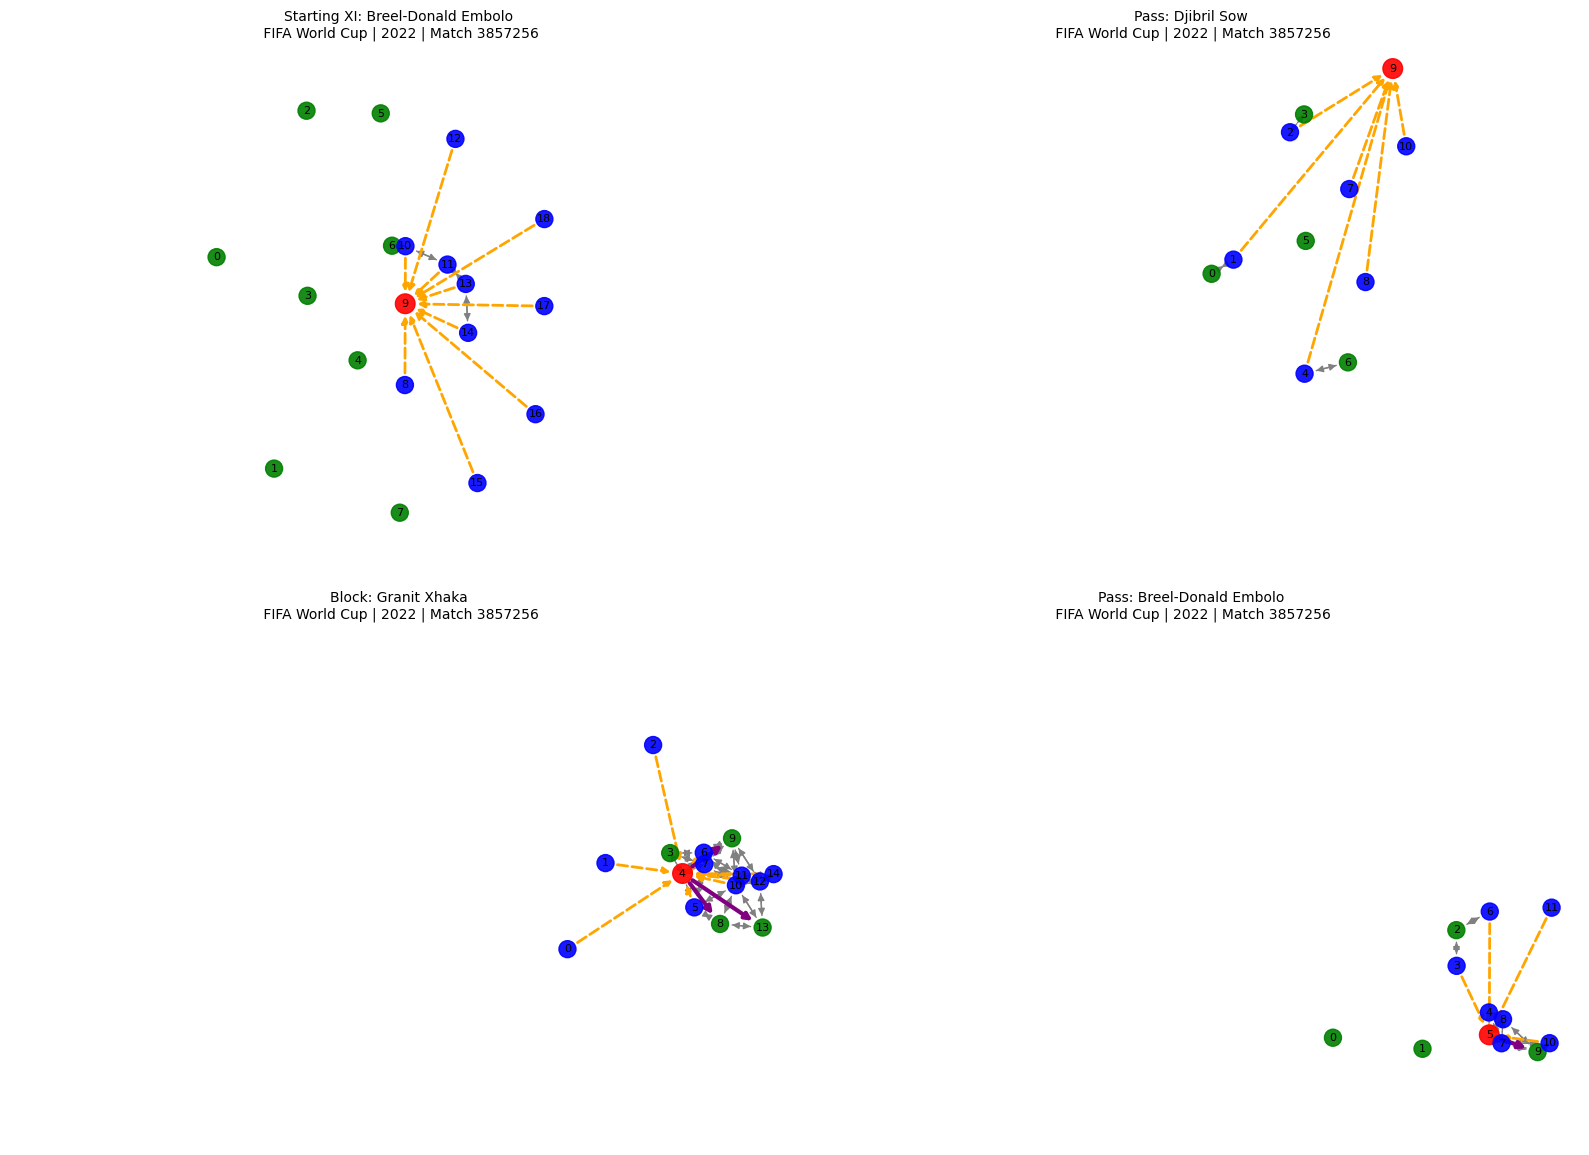

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i in range(4):
    event_graph = graphs[i*10]
    competition_name = events_full.iloc[i*10].competition
    season_name = events_full.iloc[i*10].season
    match_num = events_full.iloc[i*10].match
    event_type = events_full.iloc[i*10].type['name']
    title = f"{event_type}: {event_graph.actor_player_name}\n {competition_name} | {season_name} | Match {match_num}"
    plot_event_graph_ax(event_graph, axes[i], title)

plt.tight_layout()
plt.show()

# Buils GNN Model

https://pytorch-geometric.readthedocs.io/en/2.7.0/generated/torch_geometric.nn.conv.GINEConv.html


In [16]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GINEConv

In [17]:
class EventGNN(torch.nn.Module):
    def __init__(
        self,
        node_dim,
        edge_dim,
        num_event_types,
        hidden_dim=64,
        out_dim=64
    ):
        super().__init__()

        # Event type embedding- maps event type (integer) to dense vector
        self.event_emb = torch.nn.Embedding(num_event_types, hidden_dim)

        # Project raw node features- maps everything into shared latent space
        self.node_proj = torch.nn.Linear(node_dim, hidden_dim)

        """
        GINEConv = Graph Isomorphism Network with Edge features

        Input: node features [num_nodes, hidden_dim], edge_index, edge_attr

        Output: new node features [num_nodes, hidden_dim]

        Each node gathers information from its neighbors (connected nodes)

        Aggregates weighted by edge features (proximity, pressure, support)

        """
        self.conv1 = GINEConv(
            torch.nn.Sequential(
                torch.nn.Linear(hidden_dim, hidden_dim),
                torch.nn.ReLU()
            ),
            edge_dim=edge_dim
        )

        self.conv2 = GINEConv(
            torch.nn.Sequential(
                torch.nn.Linear(hidden_dim, out_dim),
                torch.nn.ReLU()
            ),
            edge_dim=edge_dim
        )

    def forward(self, x, edge_index, edge_attr, actor_idx, event_type_idx):
        """
        x = node features
        edge_index = adjacency
        edge_attr = edge features
        actor_idx = index of actor node in event
        event_type_idx = integer representing type of event
        """

        # Project nodes
        x = self.node_proj(x)

        # Add event type to actor node
        event_vec = self.event_emb(event_type_idx)   # [1, hidden_dim]
        x[actor_idx] = x[actor_idx] + event_vec.squeeze(0)

        # Message passing
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_attr) # x_out ∈ R^{N_nodes × hidden_dim}
        

        return x  # node embeddings


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EventGNN(
    node_dim=graphs[0].x.shape[1],
    edge_dim=graphs[0].edge_attr.shape[1],
    num_event_types=num_event_types,
    hidden_dim=64,
    out_dim=64
).to(device)

In [35]:
model.eval()

event_embeddings = []
event_metadata = []

with torch.no_grad():
    for graph in graphs:

        graph = graph.to(device)

        x_out = model(
            graph.x,
            graph.edge_index,
            graph.edge_attr,
            graph.actor_idx,
            graph.event_type_idx
        )

        actor_idx = graph.actor_idx.item()
        actor_emb = x_out[actor_idx].cpu().numpy() # extract actor embedding

        event_embeddings.append(actor_emb)

        event_metadata.append({
            "player_id": graph.actor_player_id,
            "player_name": graph.actor_player_name,
            "event_type": graph.event_type_name,
            "match_id": graph.match_id
        })


# Interpreting Model Output
- Aggregate event-level embeddings → player embeddings

- Compute player similarities

- Visualize in 2D (UMAP)

In [ ]:
import numpy as np
from collections import defaultdict

# Collect embeddings per player
player_event_embs = defaultdict(list)

for emb, meta in zip(event_embeddings, event_metadata):
    player_id = meta["player_id"]
    player_event_embs[player_id].append(emb)

# Aggregate- mean pooling across all events for each player
# player_embeddings[player_id] will given a single vector representing the player
player_embeddings = {
    pid: np.mean(np.vstack(embs), axis=0)
    for pid, embs in player_event_embs.items()
}

# Keep player names
player_mapping = {
    meta["player_id"]: meta["player_name"]
    for meta in event_metadata
}

In [58]:
from sklearn.metrics.pairwise import cosine_similarity

def player_similarity(player_id_1, player_id_2):
    v1 = player_embeddings[player_id_1].reshape(1, -1)
    v2 = player_embeddings[player_id_2].reshape(1, -1)
    return cosine_similarity(v1, v2)[0, 0]

player_ids = list(player_embeddings.keys())
player_similarity(player_ids[0], player_ids[1])


0.9959017

In [59]:
def most_similar_players(target_pid, top_k=5):
    sims = []
    for pid, emb in player_embeddings.items():
        if pid == target_pid:
            continue
        sim = cosine_similarity(
            player_embeddings[target_pid].reshape(1, -1),
            emb.reshape(1, -1)
        )[0, 0]
        sims.append((pid, sim))
    sims.sort(key=lambda x: x[1], reverse=True)
    return [(player_mapping[pid], score) for pid, score in sims[:top_k]]

# Example
most_similar_players(player_ids[0])


[('Luka Jović', 0.99972075),
 ('Aleksandar Mitrović', 0.9992217),
 ('Dušan Vlahović', 0.999165),
 ('Dušan Tadić', 0.9988708),
 ('Nemanja Radonjić', 0.9982929)]

c:\Users\sophi\anaconda3\envs\pyg\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\sophi\anaconda3\envs\pyg\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


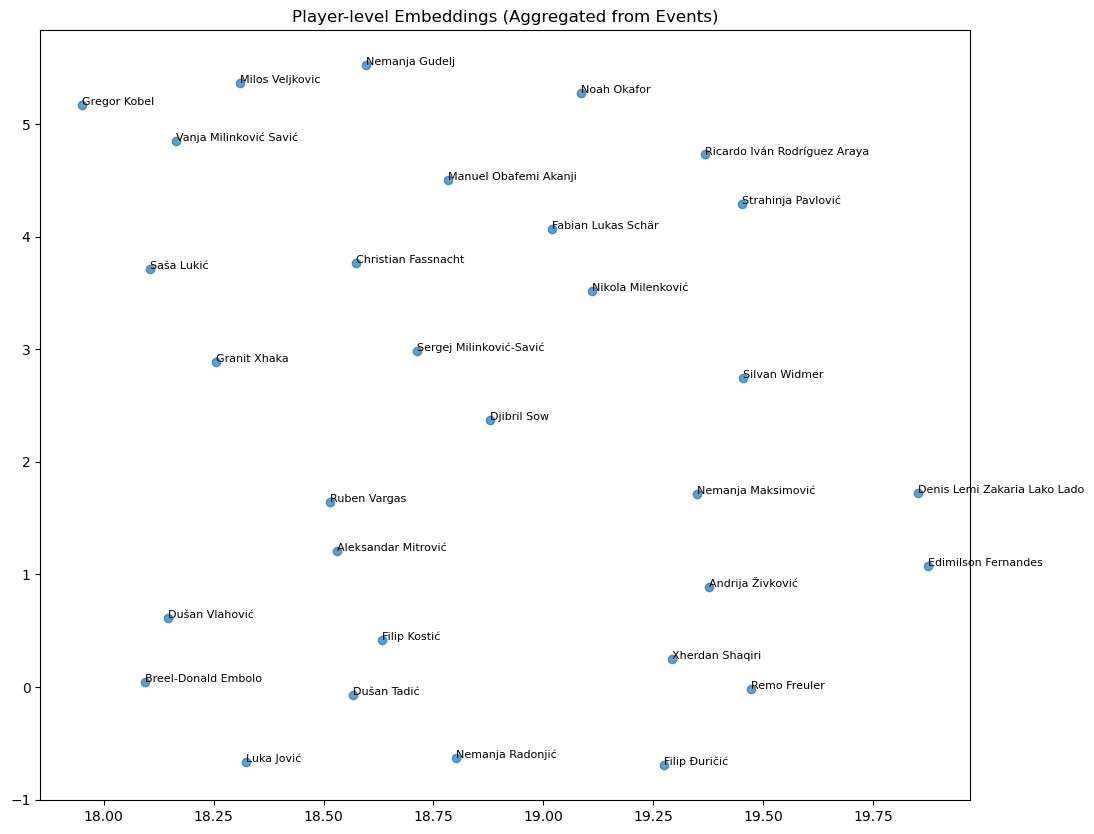

In [60]:
import umap
import matplotlib.pyplot as plt

# Prepare player embedding matrix
player_ids = list(player_embeddings.keys())
X_players = np.vstack([player_embeddings[pid] for pid in player_ids])

# Reduce to 2D
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.2,
    n_components=2,
    random_state=42
)
X_players_2d = reducer.fit_transform(X_players)

# Plot
plt.figure(figsize=(12, 10))
plt.scatter(X_players_2d[:, 0], X_players_2d[:, 1], alpha=0.7)

# Label nodes
for i, pid in enumerate(player_ids):
    plt.text(
        X_players_2d[i, 0],
        X_players_2d[i, 1],
        player_mapping.get(pid, ""),
        fontsize=8
    )

plt.title("Player-level Embeddings (Aggregated from Events)")
plt.show()


In [55]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Order players consistently
player_ids = list(player_embeddings.keys())
player_names = [player_mapping[pid] for pid in player_ids]

# Stack embeddings
X_players = np.vstack([player_embeddings[pid] for pid in player_ids])

# Compute cosine similarity matrix
sim_matrix = cosine_similarity(X_players, X_players)

# Put into DataFrame for easier plotting
sim_df = pd.DataFrame(
    sim_matrix,
    index=player_names,
    columns=player_names
)


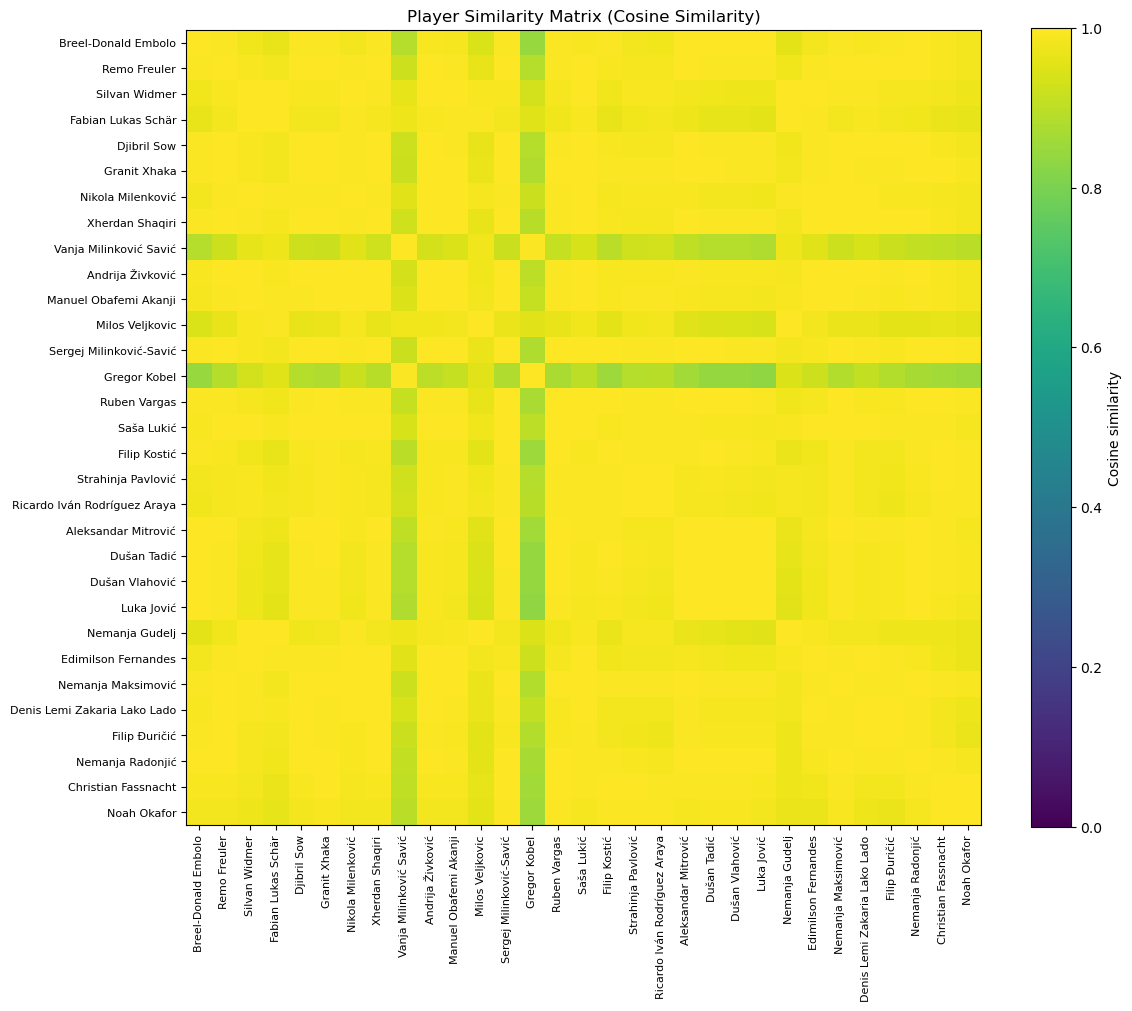

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
plt.imshow(sim_matrix, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Cosine similarity")

plt.xticks(range(len(player_names)), player_names, rotation=90, fontsize=8)
plt.yticks(range(len(player_names)), player_names, fontsize=8)

plt.title("Player Similarity Matrix (Cosine Similarity)")
plt.tight_layout()
plt.show()


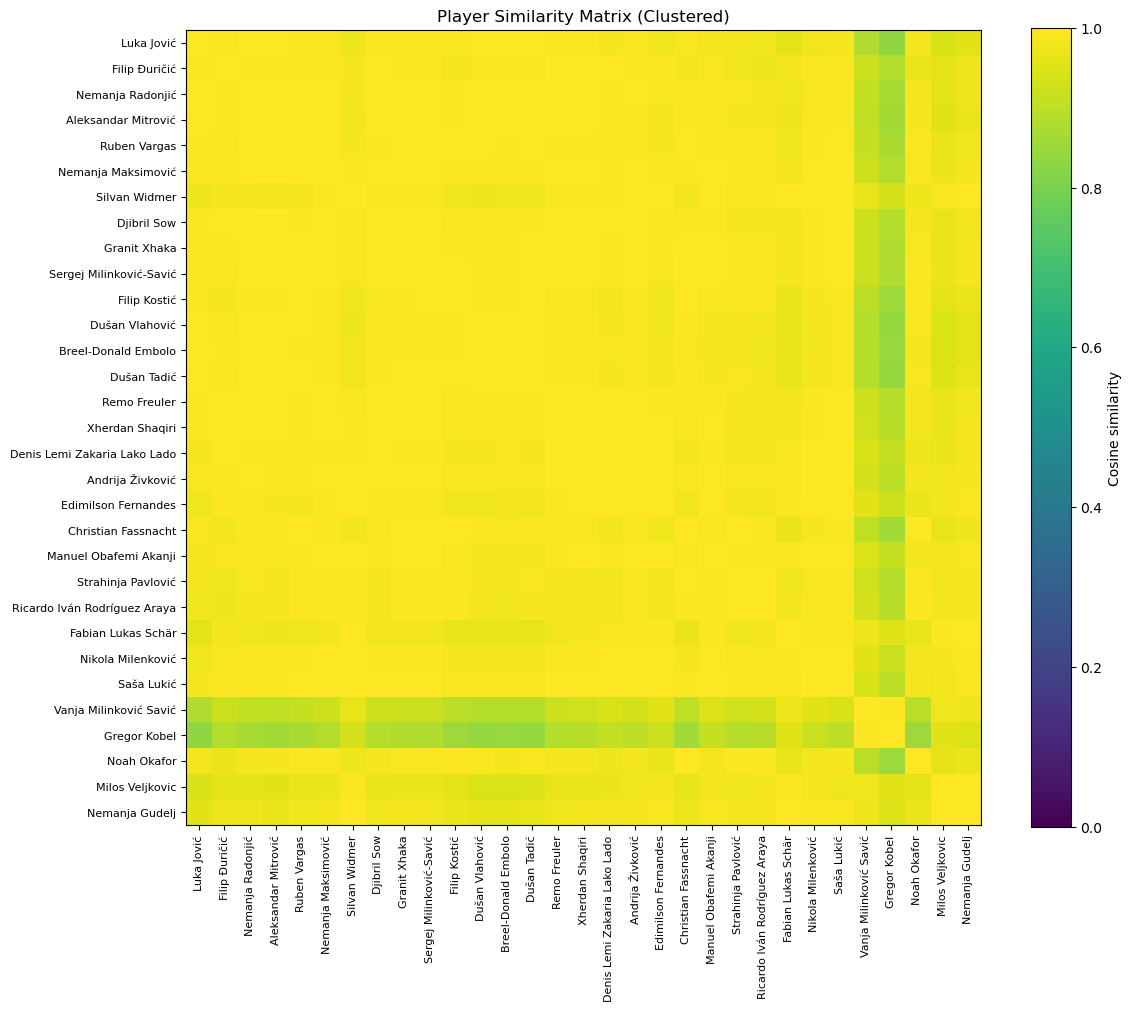

In [57]:
from scipy.cluster.hierarchy import linkage, leaves_list

# Perform hierarchical clustering
Z = linkage(X_players, method="ward")
order = leaves_list(Z)

# Reorder similarity matrix
sim_reordered = sim_matrix[order][:, order]
names_reordered = [player_names[i] for i in order]

# Plot
plt.figure(figsize=(12, 10))
plt.imshow(sim_reordered, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Cosine similarity")

plt.xticks(range(len(names_reordered)), names_reordered, rotation=90, fontsize=8)
plt.yticks(range(len(names_reordered)), names_reordered, fontsize=8)

plt.title("Player Similarity Matrix (Clustered)")
plt.tight_layout()
plt.show()
